In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [ ]:
plt.rcParams.update({
    "axes.labelsize": 12,     
    "axes.titlesize": 14, 
    "xtick.labelsize": 12,
    "ytick.labelsize": 12, 
    "legend.fontsize": 8,
})

In [ ]:
df = pd.read_csv("input_scaling_evaluation_log_rq2.csv")

grouped = (
    df.groupby(
        [
            "filter_n_atoms",
            "input_scale_factor",
            "diffusion_noise_schedule",
            "diffusion_loss_type",
        ],
        dropna=False,
    )
    .agg({"atm_stable": "mean", "mol_stable": "mean", "test_l2": "mean"})
    .reset_index()
)

mol_min, mol_max = grouped["mol_stable"].min(), grouped["mol_stable"].max()

filter_values = sorted(grouped["filter_n_atoms"].dropna().unique())
filter_values = filter_values[:4]

for (noise_schedule, loss_type), schedule_df in grouped.groupby(
    ["diffusion_noise_schedule", "diffusion_loss_type"]
):
    test_l2_min, test_l2_max = schedule_df["test_l2"].min(), schedule_df["test_l2"].max()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for i, n_atoms in enumerate(filter_values):
        ax_left = axes[i]
        sub_df = (
            schedule_df[schedule_df["filter_n_atoms"] == n_atoms]
            .sort_values("input_scale_factor")
            .reset_index(drop=True)
        )

        if sub_df.empty:
            ax_left.axis("off")
            continue

        x = sub_df["input_scale_factor"].values
        y_mol = sub_df["mol_stable"].values
        y_test = sub_df["test_l2"].values

        color_left = "tab:green"
        ax_left.set_title(f"molecule size = {n_atoms}")
        ax_left.plot(
            x,
            y_test,
            linestyle="-",
            color=color_left,
            label="L2 Loss",
        )
        ax_left.set_ylabel("L2 Loss", color=color_left)
        ax_left.tick_params(axis="y", labelcolor=color_left)
        ax_left.set_ylim(test_l2_min, test_l2_max)
        ax_left.grid(True, linestyle="--", alpha=0.4)

        idx_test_min = int(np.nanargmin(y_test))
        ax_left.plot(
            x[idx_test_min],
            y_test[idx_test_min],
            marker="x",
            markersize=10,
            markeredgewidth=2,
            color=color_left,
            zorder=5,
            label="min test_l2 (x)",
        )

        ax_right = ax_left.twinx()
        color_right = "tab:red"
        ax_right.plot(
            x,
            y_mol,
            linestyle="-",
            color=color_right,
            label="mol_stable (o)",
        )
        ax_right.set_ylabel("Molecule Stability (%)", color=color_right)
        ax_right.tick_params(axis="y", labelcolor=color_right)
        ax_right.set_ylim(mol_min, mol_max)

        idx_mol_max = int(np.nanargmax(y_mol))
        ax_right.plot(
            x[idx_mol_max],
            y_mol[idx_mol_max],
            marker="x",
            markersize=10,
            markeredgewidth=2,
            color=color_right,
            zorder=5,
            label="max mol_stable (x)",
        )

        if i >= 2:
            ax_left.set_xlabel("Input Scale Factor")

        handles = [
            Line2D([0], [0], color=color_left, label="L2 Loss"),
            Line2D([0], [0], color=color_right, label="Molecule Stability %"),
        ]
        ax_left.legend(handles=handles, loc="upper left", framealpha=0.9)

    print(
        f"Noise Schedule: {noise_schedule}   |   Loss Type: {loss_type}\n"
        f"Test L2 range: [{test_l2_min:.3f}, {test_l2_max:.3f}]   |   mol_stable global range: [{mol_min:.2f}, {mol_max:.2f}]")
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


In [1]:
import pandas as pd

# Load CSV file
df = pd.read_csv("input_scaling_evaluation_log_rq2.csv")

# Group by the specified columns and average over 'seed'
grouped = (
    df.groupby(["filter_n_atoms", "input_scale_factor", "diffusion_noise_schedule"])
    .agg({
        "mol_stable": "mean",
        "atm_stable": "mean"
    })
    .reset_index()
)

# Rename columns for clarity
grouped = grouped.rename(columns={
    "mol_stable": "avg_mol_stable",
    "atm_stable": "avg_atm_stable"
})

# Save to CSV if needed
grouped.to_csv("averaged_stability.csv", index=False)

print(grouped)


    filter_n_atoms  input_scale_factor diffusion_noise_schedule  \
0                9                 0.1             polynomial_2   
1                9                 0.2             polynomial_2   
2                9                 0.4             polynomial_2   
3                9                 0.6             polynomial_2   
4                9                 0.8             polynomial_2   
..             ...                 ...                      ...   
71              20                 6.0             polynomial_2   
72              20                 7.0             polynomial_2   
73              20                 8.0             polynomial_2   
74              20                 9.0             polynomial_2   
75              20                10.0             polynomial_2   

    avg_mol_stable  avg_atm_stable  
0         0.000000        0.325556  
1         0.000000        0.414074  
2         0.000000        0.520370  
3         0.020000        0.584815  
4         

In [3]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


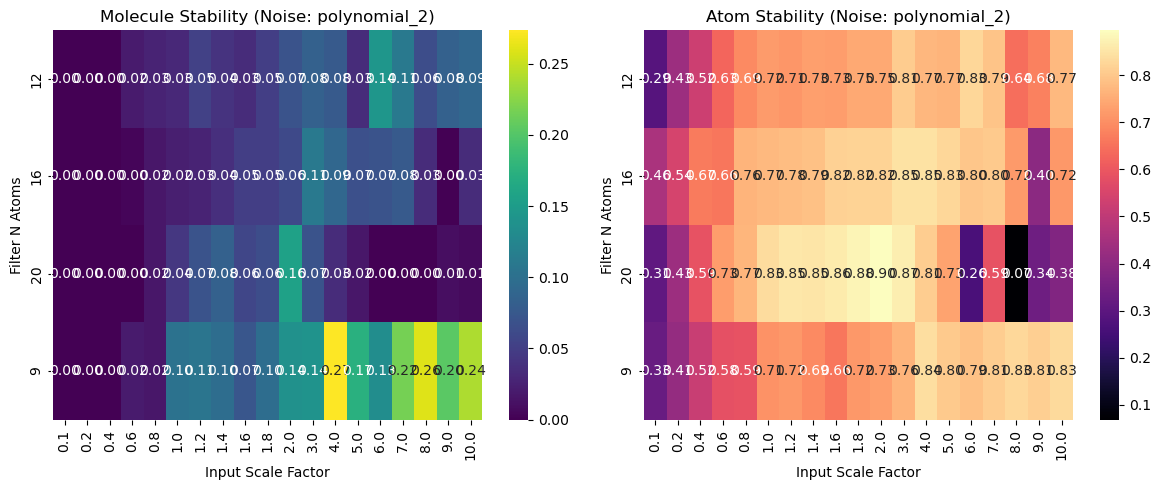

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load CSV file ===
# Replace with your actual file path, e.g. "results.csv"
df = pd.read_csv("averaged_stability.csv")

# === Ensure correct datatypes ===
df["filter_n_atoms"] = df["filter_n_atoms"].astype(str)
df["input_scale_factor"] = df["input_scale_factor"].astype(float)

# === Create heatmaps for each diffusion_noise_schedule ===
for schedule in df["diffusion_noise_schedule"].unique():
    subset = df[df["diffusion_noise_schedule"] == schedule]
    
    # Pivot tables for heatmap
    pivot_mol = subset.pivot_table(
        index="filter_n_atoms",
        columns="input_scale_factor",
        values="avg_mol_stable"
    )
    pivot_atm = subset.pivot_table(
        index="filter_n_atoms",
        columns="input_scale_factor",
        values="avg_atm_stable"
    )
    
    # Plot side-by-side heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(pivot_mol, annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
    axes[0].set_title(f"Molecule Stability (Noise: {schedule})")
    axes[0].set_xlabel("Input Scale Factor")
    axes[0].set_ylabel("Filter N Atoms")

    sns.heatmap(pivot_atm, annot=True, fmt=".2f", cmap="magma", ax=axes[1])
    axes[1].set_title(f"Atom Stability (Noise: {schedule})")
    axes[1].set_xlabel("Input Scale Factor")
    axes[1].set_ylabel("Filter N Atoms")

    plt.tight_layout()
    plt.show()
